# Machine Learning Models — Classificazione single-cell RNA-seq

In questo notebook addestriamo e confrontiamo in modo sistematico diversi
classificatori sulla *expression matrix* fornita, usando le label dei tipi
cellulari. L'obiettivo (Project 2) è: **addestrare un classificatore,
valutarne le performance con accuracy e confusion matrix, e identificare i
geni più rilevanti**.

## I modelli analizzati
1. **DummyClassifier** (`most_frequent`) — baseline triviale. Se un modello
   non supera il Dummy, non sta imparando nulla di utile.
2. **Logistic Regression** — baseline lineare interpretabile, con
   `class_weight='balanced'` per le classi rare.
3. **SVM lineare** — separabilità lineare (con PCA a 50 componenti per
   velocità, dato che abbiamo 1976 geni).
4. **Random Forest** — robusto su dati tabulari, fornisce *feature
   importance* (Gini).
5. **LightGBM** — gradient boosting, di solito il più accurato; lo usiamo
   anche per l'analisi SHAP.

> **Nota metodologica — perché queste metriche.** Il dataset è **fortemente
> sbilanciato** (CD14 Monocyte ha 1511 celle, Neutrophil solo 2). L'accuracy
> da sola è ingannevole: un modello che ignora le classi rare può avere
> accuracy alta. Per questo affianchiamo **Macro F1**, **macro precision/recall**
> e **balanced accuracy**, che pesano ugualmente tutte le classi.

> **Nota metodologica — split predefinito.** Lo split train/test è fornito dal
> corso e **non va rimescolato**; il test non si usa mai per il tuning.


In [1]:
import os
import sys, pathlib
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Modalita veloce per Colab (impostata da FullPipelineTrigger / SingleCell_Colab_Setup).
FAST_MODE = os.getenv("SC_FAST_MODE", "0").strip().lower() in ("1", "true", "yes")

# Bootstrap: trova la radice del progetto risalendo le cartelle (cerca src/).
def _find_root(start=None):
    p = (start or pathlib.Path.cwd()).resolve()
    for _ in range(6):
        if (p / "src" / "setup.py").is_file():
            return p
        if p.parent == p:
            break
        p = p.parent
    raise FileNotFoundError("Radice del progetto non trovata (manca src/setup.py).")
ROOT = _find_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", lambda v: f"{v:.4f}")
print("Project root:", ROOT)
if FAST_MODE:
    print("SC_FAST_MODE attivo: meno alberi, CV e test RF saltati.")


Project root: C:\Users\julie\Dev\GitHub\ML_SingleCell_Classification


## 1. Caricamento dati


In [2]:
from src.data_loader import load_datasets, print_shapes

X_train, X_test, y_train, y_test = load_datasets()
print_shapes(X_train, X_test, y_train, y_test)

print("\nDistribuzione classi nel train:")
print(y_train.value_counts())
print("\nDistribuzione classi nel test:")
print(y_test.value_counts())


Shape del dataset (righe = celle, colonne = geni):
  X_train: (4516, 1976)
  X_test : (1129, 1976)
  y_train: (4516,)
  y_test : (1129,)

Distribuzione classi nel train:
cell_type
CD14 Monocyte       1511
CD8m T               814
NK                   710
B                    646
CD4n T               219
Platelet             137
CD16 Monocyte        133
gd T                 127
CD4m T               108
DC                    31
CD8eff T              22
CD4 T                 20
IgA PB                15
pDC                    7
IgG PB                 4
RBC                    4
Class-switched B       3
SC & Eosinophil        3
Neutrophil             2
Name: count, dtype: int64

Distribuzione classi nel test:
cell_type
CD14 Monocyte       378
CD8m T              204
NK                  178
B                   162
CD4n T               54
Platelet             34
CD16 Monocyte        33
gd T                 32
CD4m T               27
DC                    8
CD8eff T              6
CD4 T        

## 2. Baseline triviale — DummyClassifier

Il `DummyClassifier` con `strategy='most_frequent'` predice sempre la classe
più frequente del train, senza alcun apprendimento. È il **minimo assoluto**
che ogni modello reale deve superare.


In [3]:
from sklearn.dummy import DummyClassifier
from src.metrics import compute_metrics

dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(X_train.values, y_train.values)
dummy_pred = dummy.predict(X_test.values)
dummy_metrics = compute_metrics(y_test, dummy_pred)

freq = y_train.value_counts().max() / len(y_train)
print(f"Classe più frequente nel train: '{y_train.value_counts().idxmax()}' ({freq:.1%})")
print(f"Baseline Accuracy  (Dummy): {dummy_metrics['accuracy']:.4f}")
print(f"Baseline Macro F1  (Dummy): {dummy_metrics['macro_f1']:.4f}")
print("\nOgni modello reale DEVE superare entrambe le soglie.")


Classe più frequente nel train: 'CD14 Monocyte' (33.5%)
Baseline Accuracy  (Dummy): 0.3348
Baseline Macro F1  (Dummy): 0.0295

Ogni modello reale DEVE superare entrambe le soglie.


## 3. Addestramento e valutazione dei modelli

Per ogni modello mostriamo: **metriche universali** (accuracy, macro F1,
macro precision/recall, balanced accuracy), il `classification_report` per
classe e **due confusion matrix** affiancate:
- a sinistra i **conteggi**,
- a destra la versione **normalizzata per riga** (= recall per classe), che si
  legge direttamente come "quanta parte di ogni classe vera è stata predetta
  correttamente".

Con 19 classi disattiviamo le annotazioni numeriche nella heatmap per
leggibilità (i numeri esatti sono nel `classification_report`).


In [4]:
from sklearn.metrics import classification_report, confusion_matrix
from src.models import (
    make_logistic_regression, make_svm_linear, make_random_forest,
    make_lightgbm, HAS_LIGHTGBM,
)

# Etichette ordinate (righe = vero, colonne = predetto)
LABELS = sorted(y_train.unique())


def plot_confusion_double(y_true, y_pred, title):
    """Due confusion matrix affiancate: conteggi + normalizzata per riga (recall)."""
    cm_raw = confusion_matrix(y_true, y_pred, labels=LABELS)
    cm_norm = confusion_matrix(y_true, y_pred, labels=LABELS, normalize="true")

    fig, axes = plt.subplots(1, 2, figsize=(20, 9))
    sns.heatmap(cm_raw, cmap="Blues", xticklabels=LABELS, yticklabels=LABELS,
                ax=axes[0], cbar=True)
    axes[0].set_title(f"Confusion Matrix (conteggi) — {title}")
    axes[0].set_xlabel("Predetto"); axes[0].set_ylabel("Vero")

    sns.heatmap(cm_norm, cmap="Oranges", vmin=0, vmax=1, xticklabels=LABELS,
                yticklabels=LABELS, ax=axes[1], cbar=True)
    axes[1].set_title(f"Confusion Matrix (normalizzata = recall) — {title}")
    axes[1].set_xlabel("Predetto"); axes[1].set_ylabel("Vero")

    for ax in axes:
        plt.setp(ax.get_xticklabels(), rotation=90, fontsize=8)
        plt.setp(ax.get_yticklabels(), rotation=0, fontsize=8)
    plt.tight_layout()
    plt.show()


# Definizione dei modelli reali (il Dummy è già valutato sopra)
RF_TREES = 100 if FAST_MODE else 300
LGBM_TREES = 50 if FAST_MODE else 100
models = {
    "Logistic Regression": make_logistic_regression(max_iter=1000),
    "SVM (lineare)": make_svm_linear(),
    "Random Forest": make_random_forest(n_estimators=RF_TREES),
}
if HAS_LIGHTGBM:
    models["LightGBM"] = make_lightgbm(n_estimators=LGBM_TREES, learning_rate=0.1, n_jobs=1)
else:
    print("LightGBM non disponibile — salto questo modello.")


  Addestramento: Logistic Regression


C:\Users\julie\Dev\GitHub\ML_SingleCell_Classification\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Tempo: 7.4s
Accuracy:        0.8884   (Dummy: 0.3348)
Macro F1:        0.6598   (Dummy: 0.0295)
Macro Precision: 0.6466
Macro Recall:    0.7011
Balanced Acc:    0.7011

Classification report:
                  precision    recall  f1-score   support

               B       0.99      0.99      0.99       162
   CD14 Monocyte       0.97      0.94      0.96       378
   CD16 Monocyte       0.77      0.82      0.79        33
           CD4 T       0.00      0.00      0.00         5
          CD4m T       0.50      0.33      0.40        27
          CD4n T       0.77      0.80      0.78        54
        CD8eff T       0.60      1.00      0.75         6
          CD8m T       0.81      0.86      0.83       204
Class-switched B       0.00      0.00      0.00         1
              DC       0.86      0.75      0.80         8
          IgA PB       1.00      1.00      1.00         3
          IgG PB       0.33      1.00      0.50         1
              NK       0.91      0.92      0.92      

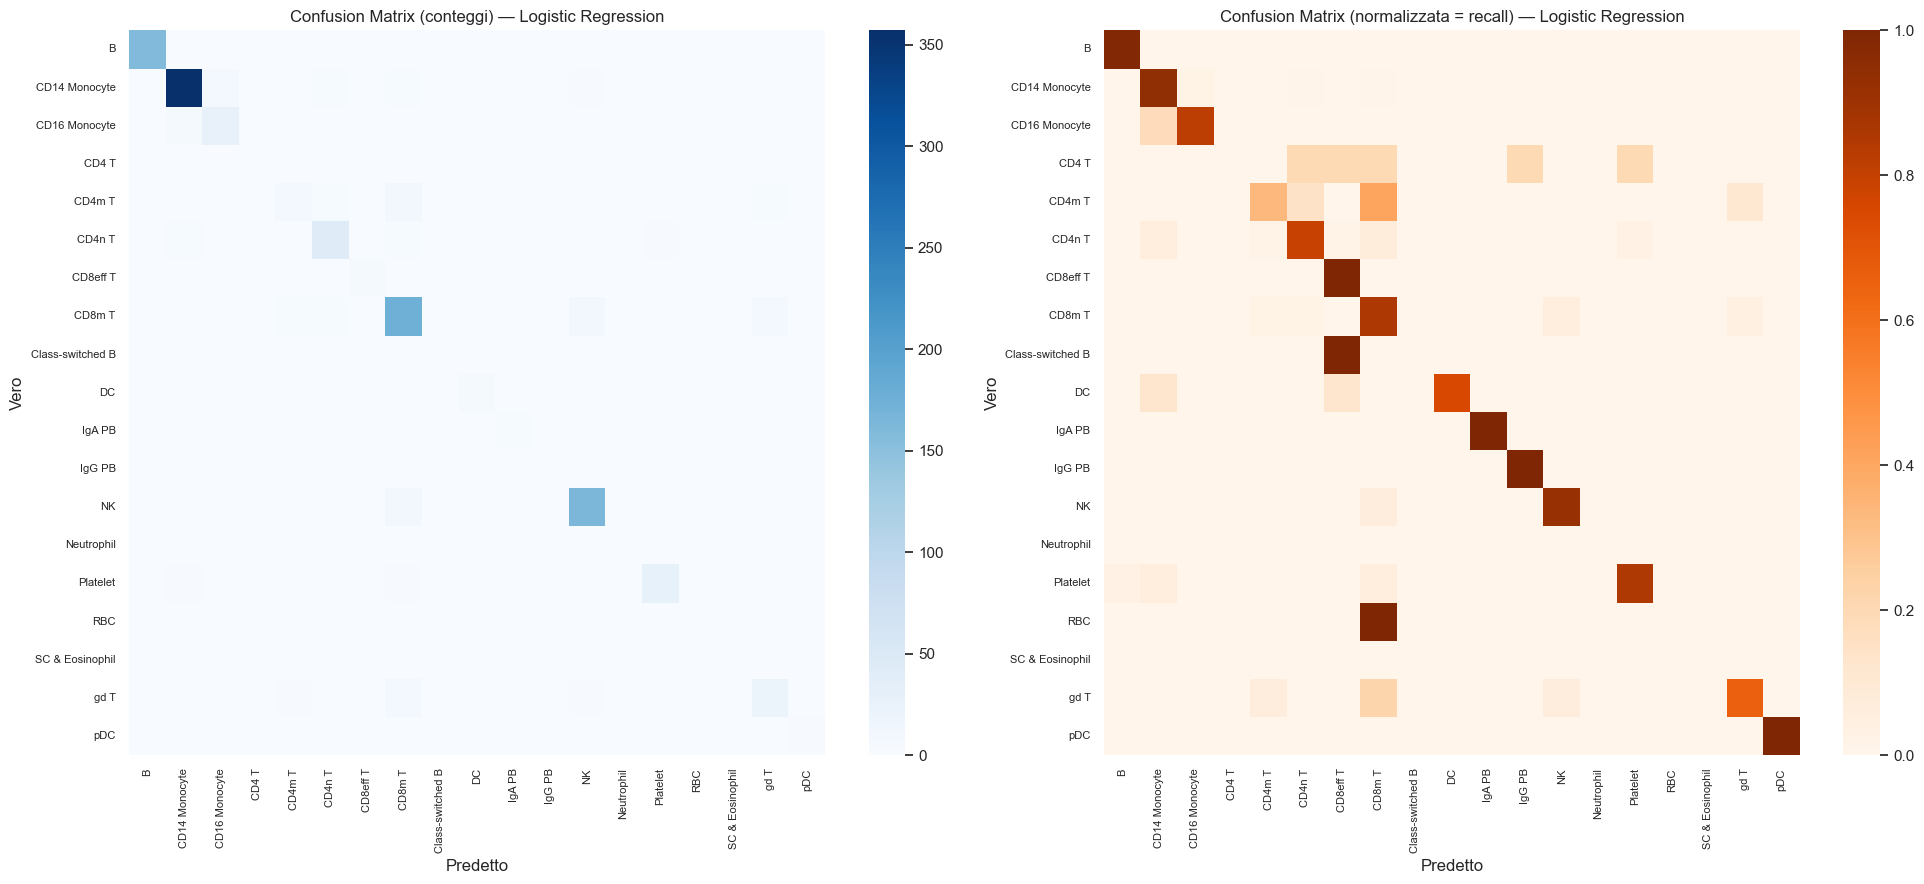

  Addestramento: SVM (lineare)


C:\Users\julie\Dev\GitHub\ML_SingleCell_Classification\venv\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Tempo: 3.1s
Accuracy:        0.8973   (Dummy: 0.3348)
Macro F1:        0.6899   (Dummy: 0.0295)
Macro Precision: 0.6710
Macro Recall:    0.7271
Balanced Acc:    0.7271

Classification report:
                  precision    recall  f1-score   support

               B       0.99      0.99      0.99       162
   CD14 Monocyte       0.97      0.95      0.96       378
   CD16 Monocyte       0.83      0.88      0.85        33
           CD4 T       0.38      0.60      0.46         5
          CD4m T       0.47      0.67      0.55        27
          CD4n T       0.75      0.83      0.79        54
        CD8eff T       1.00      1.00      1.00         6
          CD8m T       0.91      0.81      0.86       204
Class-switched B       0.00      0.00      0.00         1
              DC       0.75      0.75      0.75         8
          IgA PB       0.50      0.33      0.40         3
          IgG PB       1.00      1.00      1.00         1
              NK       0.91      0.92      0.92      

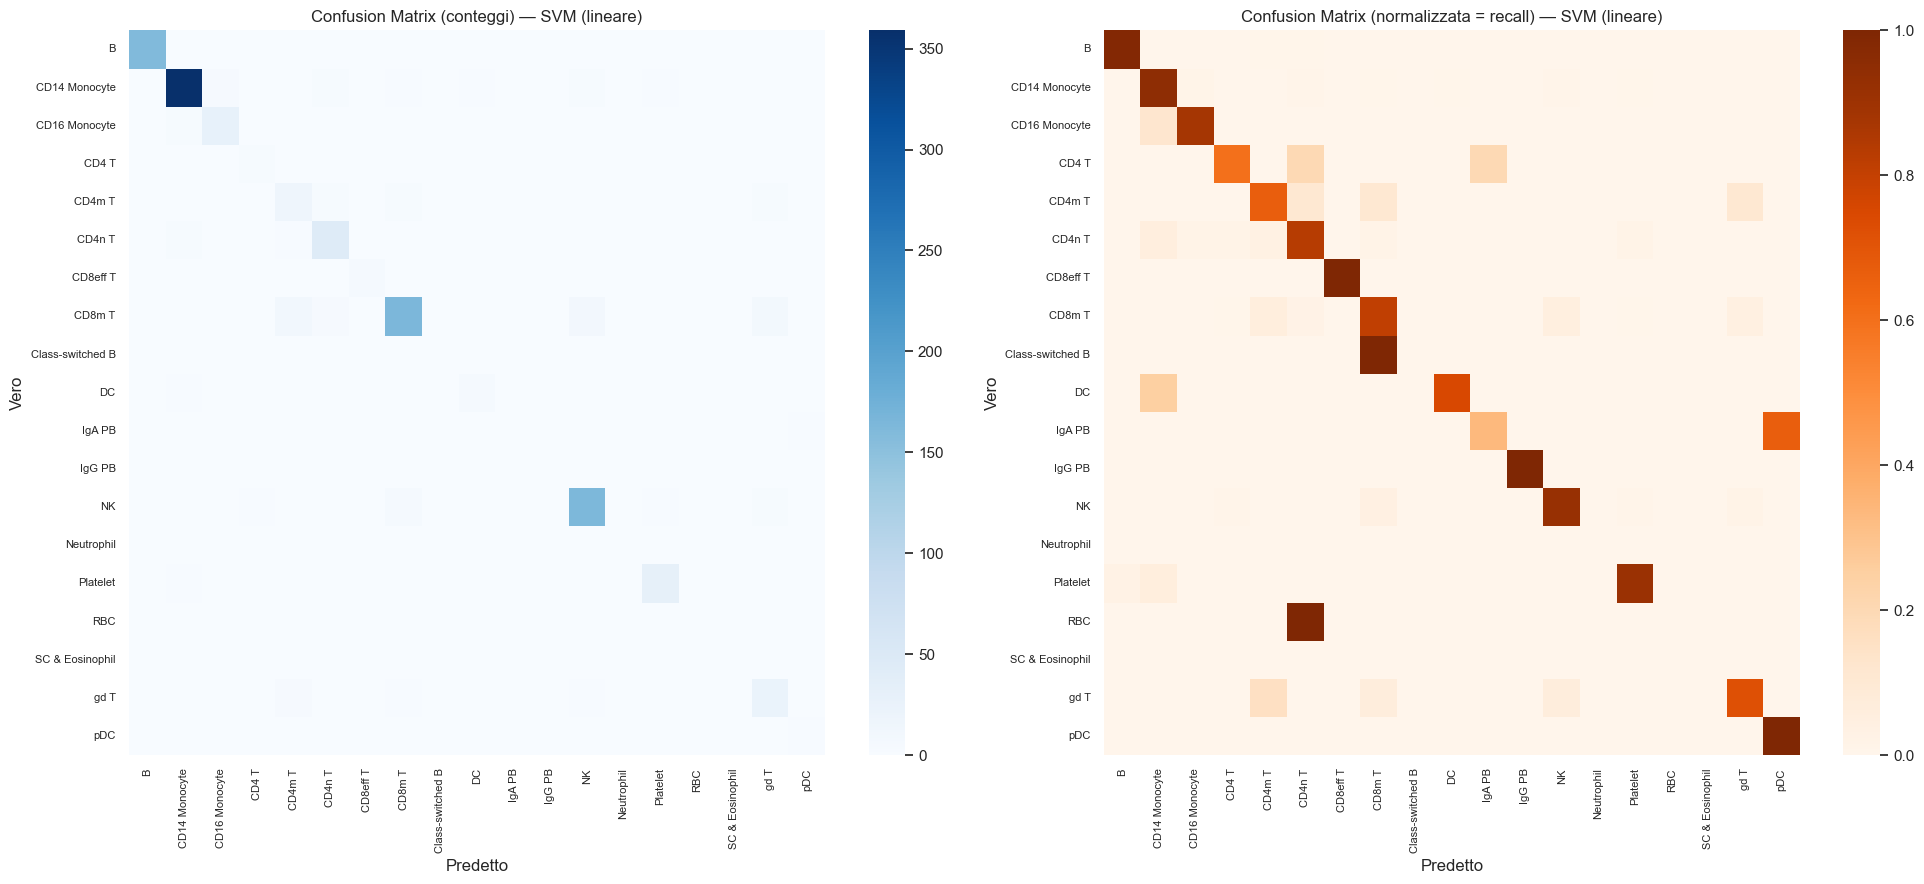

  Addestramento: Random Forest


Tempo: 4.3s
Accuracy:        0.8760   (Dummy: 0.3348)
Macro F1:        0.6277   (Dummy: 0.0295)
Macro Precision: 0.7374
Macro Recall:    0.5979
Balanced Acc:    0.5979

Classification report:
                  precision    recall  f1-score   support

               B       1.00      0.98      0.99       162
   CD14 Monocyte       0.93      0.97      0.95       378
   CD16 Monocyte       0.88      0.70      0.78        33
           CD4 T       0.00      0.00      0.00         5
          CD4m T       0.50      0.04      0.07        27
          CD4n T       0.73      0.81      0.77        54
        CD8eff T       1.00      0.67      0.80         6
          CD8m T       0.72      0.91      0.80       204
Class-switched B       0.00      0.00      0.00         1
              DC       1.00      0.62      0.77         8
          IgA PB       1.00      0.67      0.80         3
          IgG PB       1.00      1.00      1.00         1
              NK       0.90      0.94      0.92      

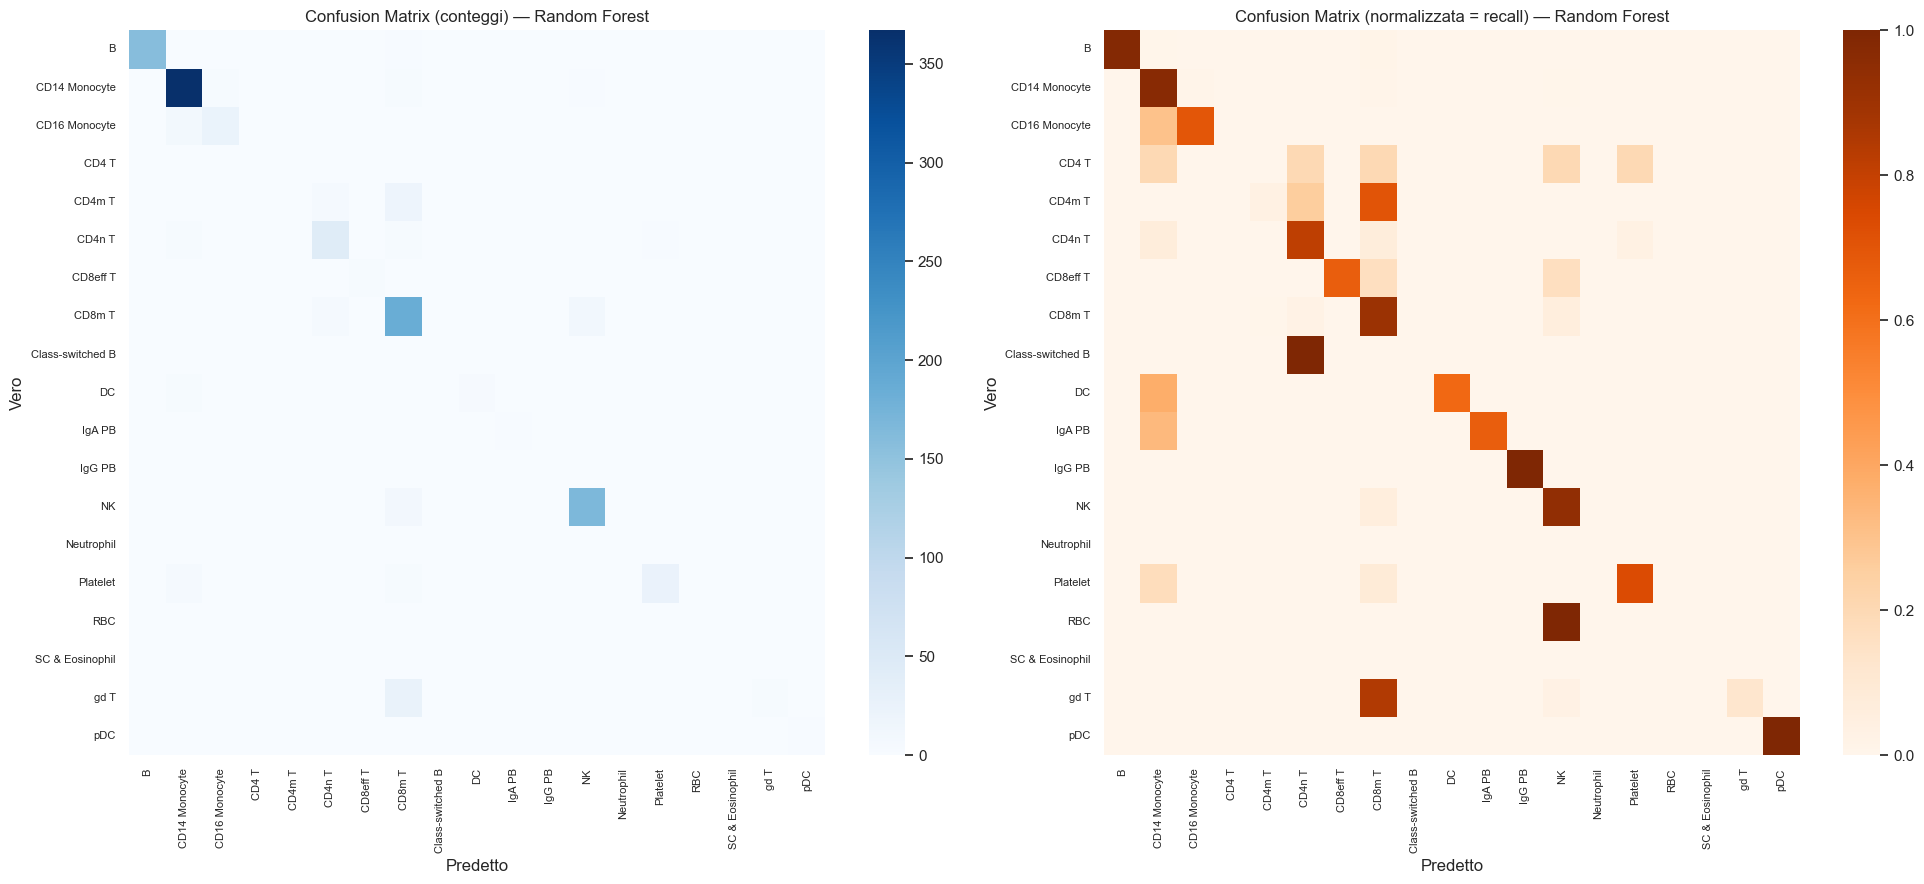

  Addestramento: LightGBM


C:\Users\julie\Dev\GitHub\ML_SingleCell_Classification\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Tempo: 197.6s
Accuracy:        0.8928   (Dummy: 0.3348)
Macro F1:        0.6120   (Dummy: 0.0295)
Macro Precision: 0.6208
Macro Recall:    0.6098
Balanced Acc:    0.6098

Classification report:
                  precision    recall  f1-score   support

               B       1.00      0.99      0.99       162
   CD14 Monocyte       0.96      0.96      0.96       378
   CD16 Monocyte       0.81      0.79      0.80        33
           CD4 T       0.00      0.00      0.00         5
          CD4m T       0.44      0.30      0.36        27
          CD4n T       0.76      0.81      0.79        54
        CD8eff T       0.60      0.50      0.55         6
          CD8m T       0.82      0.86      0.84       204
Class-switched B       0.00      0.00      0.00         1
              DC       0.83      0.62      0.71         8
          IgA PB       0.75      1.00      0.86         3
          IgG PB       0.00      0.00      0.00         1
              NK       0.89      0.93      0.91    

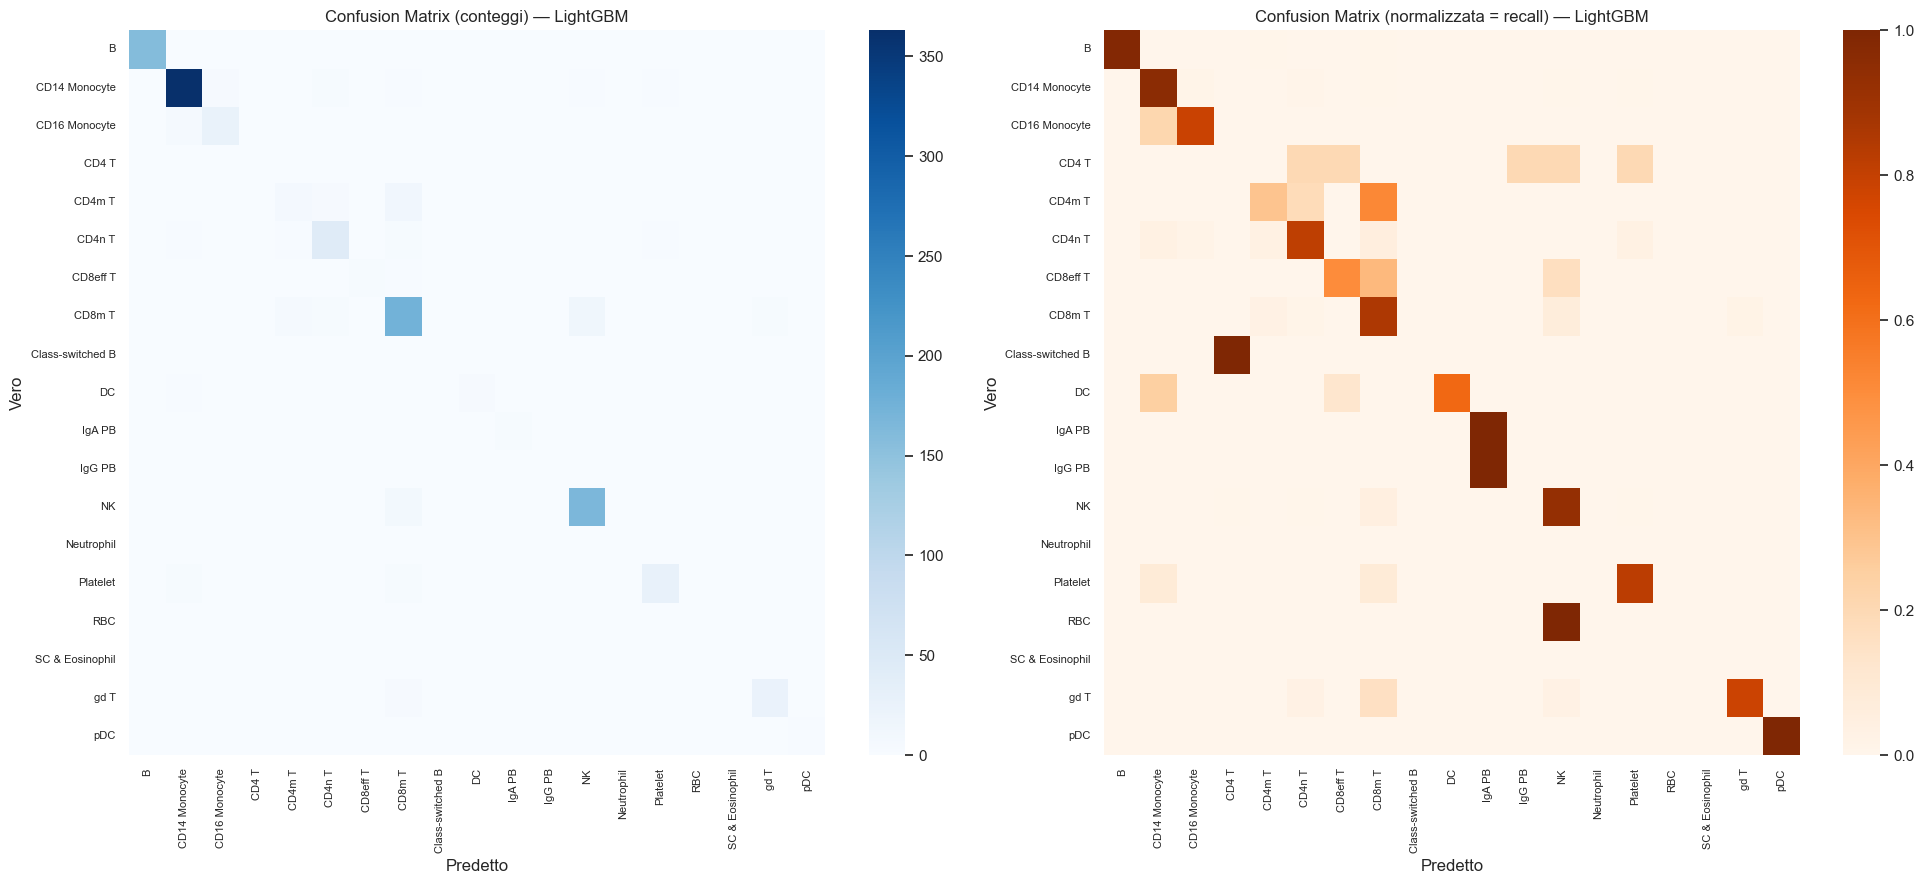

In [5]:
results = {"Dummy": dummy_metrics}        # metriche per ogni modello
fitted = {}                                # modelli addestrati (per importance/SHAP)

for name, model in models.items():
    print("=" * 60)
    print(f"  Addestramento: {name}")
    print("=" * 60)

    t0 = time.time()
    model.fit(X_train.values, y_train.values)
    y_pred = model.predict(X_test.values)
    elapsed = time.time() - t0

    m = compute_metrics(y_test, y_pred)
    results[name] = m
    fitted[name] = model

    print(f"Tempo: {elapsed:.1f}s")
    print(f"Accuracy:        {m['accuracy']:.4f}   (Dummy: {dummy_metrics['accuracy']:.4f})")
    print(f"Macro F1:        {m['macro_f1']:.4f}   (Dummy: {dummy_metrics['macro_f1']:.4f})")
    print(f"Macro Precision: {m['macro_precision']:.4f}")
    print(f"Macro Recall:    {m['macro_recall']:.4f}")
    print(f"Balanced Acc:    {m['balanced_accuracy']:.4f}")
    print("\nClassification report:")
    print(classification_report(y_test, y_pred, labels=LABELS, zero_division=0))

    plot_confusion_double(y_test, y_pred, name)


### Nota di sperimentazione — numero di alberi del Random Forest

Domanda: **conviene ridurre il numero di alberi a 5?** Pochi alberi rendono il
modello veloce ma instabile (alta varianza). Verifichiamo empiricamente l'effetto
di `n_estimators` sul Macro F1 e sul tempo di training.


In [6]:
if FAST_MODE:
    print("SC_FAST_MODE: salto il test di sensibilita su n_estimators (RF).")
else:
    rf_rows = []
    for n in [5, 50, 100, 300]:
        rf = make_random_forest(n_estimators=n)
        t0 = time.time()
        rf.fit(X_train.values, y_train.values)
        pred = rf.predict(X_test.values)
        mm = compute_metrics(y_test, pred)
        rf_rows.append({
            "n_estimators": n,
            "accuracy": round(mm["accuracy"], 4),
            "macro_f1": round(mm["macro_f1"], 4),
            "balanced_acc": round(mm["balanced_accuracy"], 4),
            "tempo_s": round(time.time() - t0, 1),
        })

    rf_test = pd.DataFrame(rf_rows).set_index("n_estimators")
    print("Effetto del numero di alberi (Random Forest):")
    print(rf_test.to_string())
    print("\nLettura: con soli 5 alberi le metriche calano e diventano instabili;")
    print("oltre ~100 alberi il guadagno è marginale ma il tempo cresce.")


Effetto del numero di alberi (Random Forest):
              accuracy  macro_f1  balanced_acc  tempo_s
n_estimators                                           
5               0.8246    0.5065        0.4702   0.5000
50              0.8787    0.6568        0.6345   1.3000
100             0.8822    0.6509        0.6266   2.1000
300             0.8760    0.6277        0.5979   5.3000

Lettura: con soli 5 alberi le metriche calano e diventano instabili;
oltre ~100 alberi il guadagno è marginale ma il tempo cresce.


## 4. Confronto delle performance

Confrontiamo i modelli su **Accuracy** e **Macro F1** affiancati. La linea
rossa tratteggiata è la baseline del Dummy: sotto quella soglia un modello non
aggiunge valore.


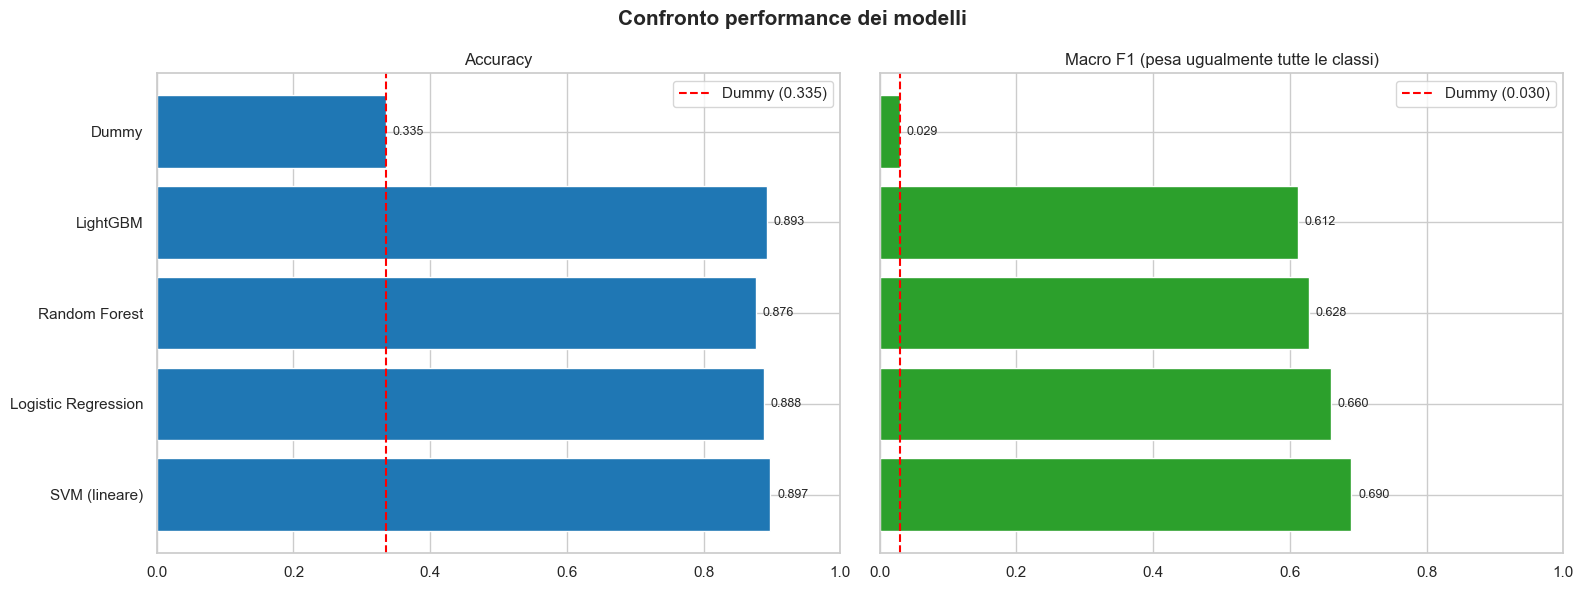


=== Riepilogo finale (ordinato per Macro F1) ===
                     accuracy  macro_f1  macro_precision  macro_recall  weighted_f1  balanced_accuracy
SVM (lineare)          0.8973    0.6899           0.6710        0.7271       0.8995             0.7271
Logistic Regression    0.8884    0.6598           0.6466        0.7011       0.8851             0.7011
Random Forest          0.8760    0.6277           0.7374        0.5979       0.8570             0.5979
LightGBM               0.8928    0.6120           0.6208        0.6098       0.8888             0.6098
Dummy                  0.3348    0.0295           0.0197        0.0588       0.1680             0.0588


In [7]:
summary = pd.DataFrame(results).T
summary = summary[["accuracy", "macro_f1", "macro_precision", "macro_recall",
                   "weighted_f1", "balanced_accuracy"]].round(4)
summary = summary.sort_values("macro_f1", ascending=False)

names = summary.index.tolist()
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
fig.suptitle("Confronto performance dei modelli", fontsize=15, fontweight="bold")

axes[0].barh(names, summary["accuracy"], color="#1f77b4")
axes[0].axvline(dummy_metrics["accuracy"], color="red", ls="--",
                label=f"Dummy ({dummy_metrics['accuracy']:.3f})")
axes[0].set_title("Accuracy"); axes[0].set_xlim(0, 1); axes[0].legend()
for i, v in enumerate(summary["accuracy"]):
    axes[0].text(v + 0.01, i, f"{v:.3f}", va="center", fontsize=9)

axes[1].barh(names, summary["macro_f1"], color="#2ca02c")
axes[1].axvline(dummy_metrics["macro_f1"], color="red", ls="--",
                label=f"Dummy ({dummy_metrics['macro_f1']:.3f})")
axes[1].set_title("Macro F1 (pesa ugualmente tutte le classi)")
axes[1].set_xlim(0, 1); axes[1].legend()
for i, v in enumerate(summary["macro_f1"]):
    axes[1].text(v + 0.01, i, f"{v:.3f}", va="center", fontsize=9)

axes[0].invert_yaxis(); axes[1].invert_yaxis()
plt.tight_layout(); plt.show()

print("\n=== Riepilogo finale (ordinato per Macro F1) ===")
print(summary.to_string())


## 5. Cross-validation

Per non dipendere da un singolo split, valutiamo i modelli **sul train** con
una cross-validation stratificata (mantiene le proporzioni delle classi in ogni
porzione) e metrica `f1_macro`. Poiché alcune classi hanno pochissime celle,
adattiamo automaticamente il numero di porzioni alla classe più rara.


In [8]:
cv_results = {}

if FAST_MODE:
    print("SC_FAST_MODE: salto la cross-validation (sezione 5).")
else:
    from collections import Counter
    from sklearn.model_selection import StratifiedKFold, cross_val_score

    min_class = min(Counter(y_train).values())
    n_splits = min(5, min_class)
    rare = {c: n for c, n in Counter(y_train).items() if n < 5}
    print(f"Classe più rara nel train: {min_class} celle -> uso n_splits = {n_splits}")
    if rare:
        print("Classi con meno di 5 celle (limitano il numero di fold):")
        for c, n in sorted(rare.items(), key=lambda x: x[1]):
            print(f"  {c}: {n}")

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    cv_models = {"Dummy": DummyClassifier(strategy="most_frequent", random_state=42)}
    cv_models.update(models)

    for name, model in cv_models.items():
        scores = cross_val_score(model, X_train.values, y_train.values,
                                 cv=skf, scoring="f1_macro", n_jobs=-1)
        cv_results[name] = scores
        print(f"{name:22s}  Macro F1 (CV): {scores.mean():.4f} +/- {scores.std():.4f}")


Classe più rara nel train: 2 celle -> uso n_splits = 2
Classi con meno di 5 celle (limitano il numero di fold):
  Neutrophil: 2
  Class-switched B: 3
  SC & Eosinophil: 3
  IgG PB: 4
  RBC: 4


Dummy                   Macro F1 (CV): 0.0264 +/- 0.0000


Logistic Regression     Macro F1 (CV): 0.5717 +/- 0.0157


SVM (lineare)           Macro F1 (CV): 0.5491 +/- 0.0183


Random Forest           Macro F1 (CV): 0.4072 +/- 0.0089


LightGBM                Macro F1 (CV): 0.5391 +/- 0.0180


### Tabella unificata: Test set + Cross-validation

Mettiamo a confronto le metriche del **singolo split di test** con la **CV**.
Se i valori sono vicini, il risultato è stabile.


In [9]:
if FAST_MODE:
    print("SC_FAST_MODE: tabella unificata CV non disponibile (CV saltata).")
    print("\n=== Riepilogo test set (ordinato per Macro F1) ===")
    test_only = pd.DataFrame({
        "Test Accuracy": {n: results[n]["accuracy"] for n in results},
        "Test Macro F1": {n: results[n]["macro_f1"] for n in results},
    }).round(4).sort_values("Test Macro F1", ascending=False)
    print(test_only.to_string())
else:
    unified = pd.DataFrame({
        "Test Accuracy": {n: results[n]["accuracy"] for n in cv_results},
        "Test Macro F1": {n: results[n]["macro_f1"] for n in cv_results},
        "CV Macro F1 (mean)": {n: cv_results[n].mean() for n in cv_results},
        "CV Macro F1 (std)": {n: cv_results[n].std() for n in cv_results},
    }).round(4).sort_values("Test Macro F1", ascending=False)

    unified["CV Macro F1 (mean +/- std)"] = [
        f"{m:.4f} +/- {s:.4f}"
        for m, s in zip(unified["CV Macro F1 (mean)"], unified["CV Macro F1 (std)"])
    ]

    print("=" * 70)
    print("  RIEPILOGO: Test set + Cross-validation")
    print("=" * 70)
    print(unified[["Test Accuracy", "Test Macro F1", "CV Macro F1 (mean +/- std)"]].to_string())


  RIEPILOGO: Test set + Cross-validation
                     Test Accuracy  Test Macro F1 CV Macro F1 (mean +/- std)
SVM (lineare)               0.8973         0.6899          0.5491 +/- 0.0183
Logistic Regression         0.8884         0.6598          0.5717 +/- 0.0157
Random Forest               0.8760         0.6277          0.4072 +/- 0.0089
LightGBM                    0.8928         0.6120          0.5391 +/- 0.0180
Dummy                       0.3348         0.0295          0.0264 +/- 0.0000


## 6. Feature importance — geni più rilevanti

Per i modelli ad albero (Random Forest, LightGBM) estraiamo l'importanza delle
feature: quali **geni** pesano di più nelle decisioni del modello. Questo
risponde direttamente alla richiesta della tutora ("identificare i geni più
rilevanti").


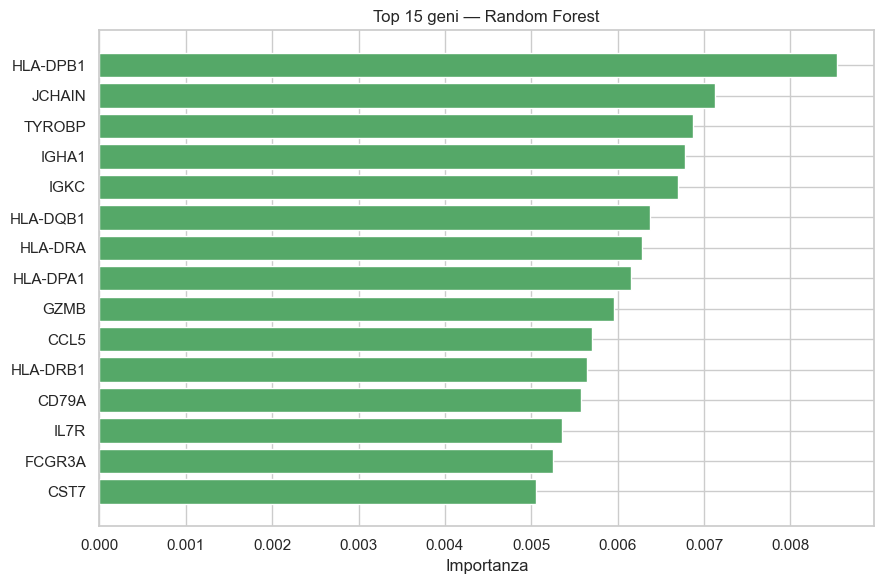

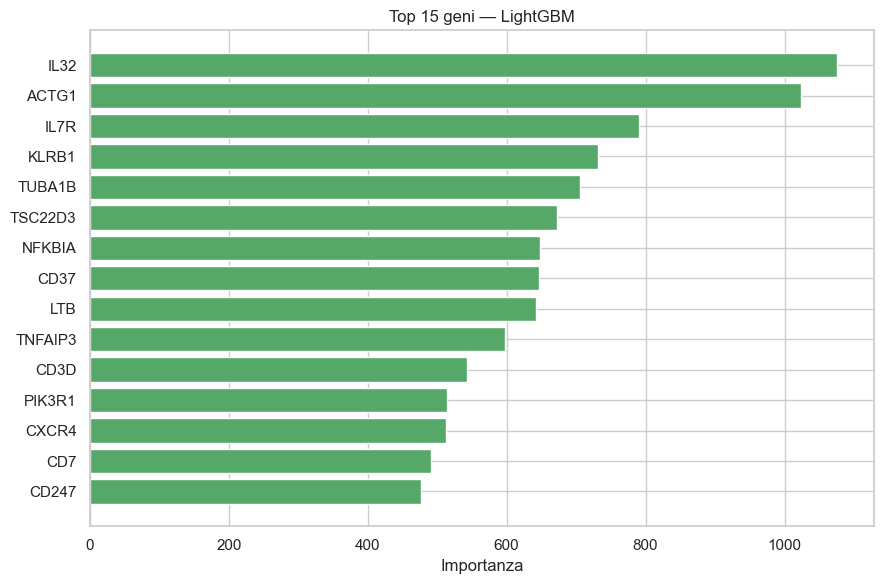

In [10]:
def plot_top_importance(model, title, top_n=15):
    imp = pd.Series(model.feature_importances_, index=X_train.columns)
    top = imp.sort_values(ascending=False).head(top_n)[::-1]
    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh(top.index, top.values, color="#55a868")
    ax.set_title(f"Top {top_n} geni — {title}")
    ax.set_xlabel("Importanza")
    plt.tight_layout(); plt.show()
    return imp

importances = {}
for name in ["Random Forest", "LightGBM"]:
    if name in fitted and hasattr(fitted[name], "feature_importances_"):
        importances[name] = plot_top_importance(fitted[name], name)


## 6b. SHAP — interpretabilità per classe

La feature importance dice *quali geni contano in media*. **SHAP** dice
*quanto e in che direzione* ogni gene contribuisce, **per classe**. Mostriamo
prima il **summary globale** sul miglior modello ad alberi, poi calcoliamo il
`|SHAP|` medio per classe sui geni richiesti dalla tutora (**IL7R, PF4, CD3E**):
così verifichiamo che non siano stati scelti a priori ma emergano dal modello
come più influenti per le classi attese (T-cell, Platelet).


SHAP sul modello: LightGBM


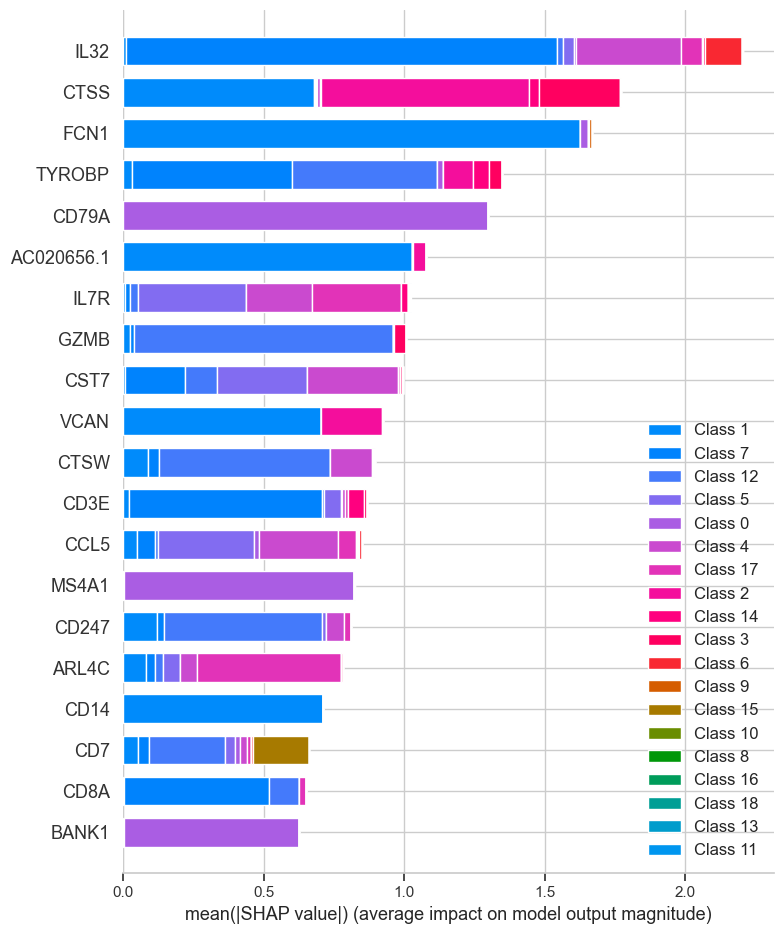


|SHAP| medio per classe (gene -> classe più influenzata):
   IL7R -> CD4n T  (|SHAP|=0.384)
    PF4 -> Platelet  (|SHAP|=0.434)
   CD3E -> CD8m T  (|SHAP|=0.688)


In [11]:
try:
    import shap

    # miglior modello ad alberi per accuracy
    tree_models = [n for n in ["LightGBM", "Random Forest"] if n in fitted]
    best_tree = max(tree_models, key=lambda n: results[n]["accuracy"])
    print(f"SHAP sul modello: {best_tree}")

    shap_n = 50 if FAST_MODE else 200
    rng = np.random.default_rng(42)
    idx = rng.choice(len(X_test), size=min(shap_n, len(X_test)), replace=False)
    X_sample = X_test.iloc[idx]

    explainer = shap.TreeExplainer(fitted[best_tree])
    shap_values = explainer.shap_values(X_sample.values)

    shap.summary_plot(shap_values, X_sample, feature_names=list(X_sample.columns),
                      plot_type="bar", max_display=20, show=True)

    # Normalizziamo i valori SHAP in una lista per-classe (shape: campioni x geni).
    if isinstance(shap_values, list):
        sv_per_class = shap_values
    else:
        sv_per_class = [shap_values[:, :, c] for c in range(shap_values.shape[-1])]

    # |SHAP| medio per classe sui geni richiesti dalla tutora.
    classes = list(fitted[best_tree].classes_)
    rows = []
    for gene in ["IL7R", "PF4", "CD3E"]:
        if gene not in X_sample.columns:
            print(f"ATTENZIONE: {gene} non presente negli HVG."); continue
        gi = X_sample.columns.get_loc(gene)
        rows.append(pd.Series(
            {cls: float(np.abs(sv_per_class[ci][:, gi]).mean())
             for ci, cls in enumerate(classes)}, name=gene))
    shap_by_class = pd.DataFrame(rows)
    print("\n|SHAP| medio per classe (gene -> classe più influenzata):")
    for gene in shap_by_class.index:
        top_cls = shap_by_class.loc[gene].idxmax()
        print(f"  {gene:>5s} -> {top_cls}  (|SHAP|={shap_by_class.loc[gene].max():.3f})")
except ImportError:
    print("shap non installato: pip install shap")


---
**Conclusioni.** Confronta i modelli con la baseline Dummy: i modelli reali la
superano nettamente in accuracy e Macro F1. Il Macro F1 e la confusion matrix
normalizzata evidenziano le classi rare difficili da predire. I geni più
rilevanti emergono dalla feature importance e da SHAP: in particolare IL7R, PF4
e CD3E risultano più influenti proprio per le classi attese (T-cell, Platelet),
a conferma che non sono stati scelti a priori.
